# Automatic Evaluation 

### Init

In [1]:
import pandas as pd 
import numpy as np
import pickle
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# From variables 
criteria = ["Completeness", "Step-by-step concordance", "Case-tailoring concordance", "Missing data concordance"]
approaches = ["Model_Alone", "Model_Studies", "Model_Workflow", "Model_Workflow_Studies"]
approaches_names_map = {"Model_Alone":"LLM-out-of-the-box", "Model_Studies":"RAG-LLM", "Model_Workflow":"WF-LLM", "Model_Workflow_Studies":"WF-RAG-LLM"}

step2_labels = ["Cancer_Surgery", "Imaging_Test", "Therapy"]
step3_labels = ["Biomarker","Biomarker_Result", "Cancer_Surgery", "Grade","Histological_Type","Imaging_Test","Invasion", "Metastasis", "Oncogene", "Response_To_Treatment",
          "Staging","Therapy","Tumor_Finding","Tumor_Size"]

In [3]:
n_case_eval = 30

### LLM-as-Judge Approach results

In [4]:
data_dir = "results/"
model = "gpt"
strategy = "OneText"
version = "v3"

with open(f"{data_dir}complete_results_{model}_{strategy}_{version}.pickle", "rb") as f:
    complete_res = pickle.load(f)

In [5]:
complete_res["Case-tailoring concordance"]["Model_Alone"].iloc[-3:,:]

,Case_Number,Case_Content,Response,Reference,LLMEval
27,28.0,NaN,Step 1 - Oncological strategy \n- Initiate sy...,Step 1 – Resectability assessment\nThe patient...,NOT SATISFIED
28,29.0,NaN,Step 1 – Oncological strategy \n- Obtain comp...,Step 1 – Resectability assessment\nThe patient...,NOT SATISFIED
29,30.0,NaN,Step 1 – Oncological strategy \n- Confirm abs...,Step 1 – Resectability assessment\nThe patient...,SATISFIED


In [6]:
# Percentage of SATISFIED criteria for each approach 
res_tb = pd.DataFrame(columns=criteria, index=approaches)

for c in criteria:
    for a in approaches:
        evals = complete_res[c][a]["LLMEval"].values
        if len(evals) != n_case_eval:
            print(f"Warning about the number of cases for criterion {c}, approach {a}")
        else:
            pos_evals = [e for e in evals if e == "SATISFIED"]
            p = round((len(pos_evals)/len(evals))*100,2)
            res_tb.loc[a, c] = f"{len(pos_evals)} ({p}%)"

In [7]:
res_tb

,Completeness,Step-by-step concordance,Case-tailoring concordance,Missing data concordance
Model_Alone,6 (20.0%),4 (13.33%),12 (40.0%),2 (6.67%)
Model_Studies,5 (16.67%),3 (10.0%),9 (30.0%),5 (16.67%)
Model_Workflow,11 (36.67%),2 (6.67%),14 (46.67%),8 (26.67%)
Model_Workflow_Studies,13 (43.33%),4 (13.33%),15 (50.0%),17 (56.67%)


In [13]:
res_tb.to_csv(f"{data_dir}/criteria_stats_claude.csv")

### Step 1: Resectability Label Comparison

In [13]:
# Read the resectability labels extracted from Step1
data_dir = "data/"
res_dir = "results/"
strategy = "OneText"
version = "v3"

n_case_eval = 100

step1_label_data = pd.read_csv(f"{data_dir}{version}/resectability_label_{version}.csv")

In [9]:
labels=["upfront resectable", "potentially resectable", "not resectable"]

In [14]:
labels_approach = {a:[] for a in approaches} 
for a in approaches:
    model_labels = step1_label_data.loc[step1_label_data["Approach"]==a, "Resectability_Label"].to_list()
    if len(model_labels) != n_case_eval:
        print(f"Warning with approach {a}; {len(model_labels)}")
    else:
        labels_approach[a] = model_labels

In [15]:
expert_labels = step1_label_data.loc[step1_label_data["Approach"]=="Expert", "Resectability_Label"].to_list()
print(len(expert_labels))

100


In [16]:
# Accuracy table
acc_tb = pd.DataFrame(columns=["Accuracy"], index=approaches)
for a in labels_approach.keys():
    true_s = 0
    for i in range(0, len(expert_labels)):
        if labels_approach[a][i] == expert_labels[i]:
            true_s += 1
    acc = round(true_s/len(expert_labels),3)
    acc_tb.loc[a, "Accuracy"] = acc

# acc_tb.to_csv(f"{res_dir}resectability_accuracy.csv")
        

In [17]:
# Per-label Accuracy table
acc_tb = pd.DataFrame(columns=[f"Count_{l}" for l in labels]+[f"Accuracy_{l}" for l in labels], index=approaches)
for a in labels_approach.keys():
    #print(f"Approach: {a}")
    true_s = {l:0 for l in labels}
    for i in range(0, len(expert_labels)):
        if labels_approach[a][i] == expert_labels[i]:
            true_s[expert_labels[i]] += 1
    for l in labels:
        #print(f"Label: {l}; {true_s[l]}/{len([t for t in expert_labels if t == l])}")
        acc = round(true_s[l]/len([t for t in expert_labels if t == l]),3)
        acc_tb.loc[a, f"Count_{l}"] = len([t for t in expert_labels if t == l])
        acc_tb.loc[a, f"Accuracy_{l}"] = acc

# acc_tb.to_csv(f"{res_dir}resectability_accuracy_per_label.csv")

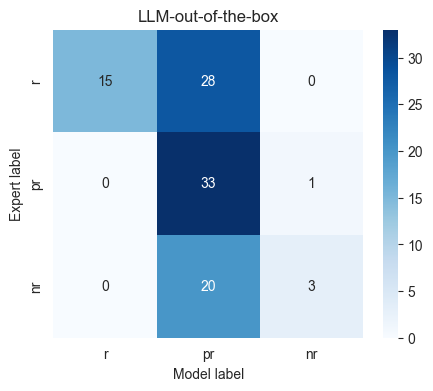

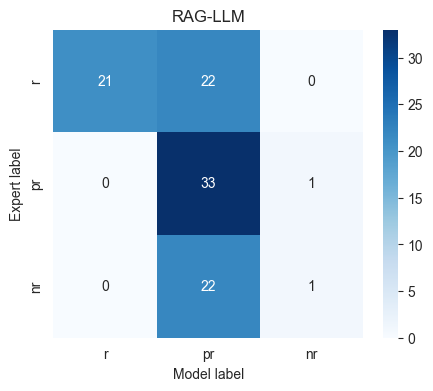

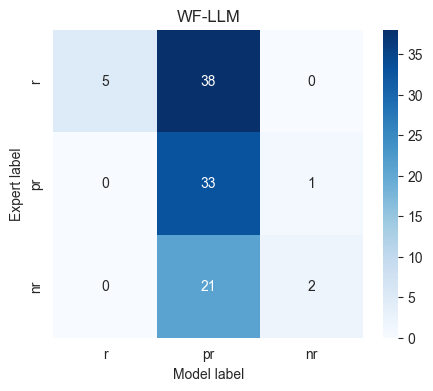

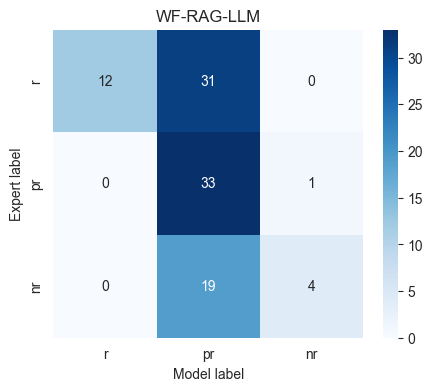

In [47]:
categories = ["r", "pr", "nr"]
for a in labels_approach.keys():
    cm = confusion_matrix(expert_labels, labels_approach[a], labels=labels)
    fig = plt.figure(figsize=(5,4))
    sns.heatmap(cm, cmap="Blues", annot=True, xticklabels=categories, yticklabels=categories)
    plt.ylabel('Expert label')
    plt.xlabel('Model label')
    plt.title(approaches_names_map[a])
    fig.savefig(f"{res_dir}resectability_confusion_matrix/{a}.png", dpi=600, format="png", bbox_inches='tight')
    

### NER Analysis Results

In [4]:
metrics = ["LCS","TSR","Levenshtein","Exact_Match_P"]
data_dir = "results_ner/"

In [ ]:
# Check the number of cases for each metric results 
semantic_data = {m:{s: {a: {} for a in approaches} for s in ["Step12", "Step3"]} for m in metrics[1:]}
lcs_data = {}

for m in metrics:
    if m == "LCS":
        f_name_begin = f"NER_{m}_Step12_"
        for a in approaches:
            data = pd.read_csv(f"{data_dir}{f_name_begin}{a}.csv")
            if len(data) != n_case_eval:
                print(f"Warning <data_len> for {m} data, Approach {a}")
            else:
                lcs_data[a] = data
    else:
        for s in ["Step2", "Step3"]:
            f_name_begin = f"NER_semantic_metric_{s}_"
            for a in approaches:
                data_dict = {}
                data = pd.read_csv(f"{data_dir}{f_name_begin}{a}.csv")
                data_m = data.loc[data["Metric"]==m]
                entity = set(data_m["Label"])
                if s == "Step2":
                    external_entity = [e for e in entity if e not in step12_labels]
                else:
                    external_entity = [e for e in entity if e not in step3_labels]
                if len(external_entity) == 0:
                    for e in entity:
                        data_m_e = data_m.loc[data_m["Label"]==e]
                        if len(data_m_e) != n_case_eval:
                            print(f"Warning <data_len> for {m} data, Approach: {a}, Entity: {e}")
                        else:
                            data_dict[e] = data_m_e
                else:
                    print(f"Warning <external_entities> for {m} data, Approach: {a}, Entity: {e}")
                semantic_data[m][s].update({a:data_dict})


In [14]:
# print("LSC Data")
# for a in lcs_data.keys():
#     print(f"Approach: {a} --> {len(lcs_data[a])}")

# print("Semantic Data")
# for m in semantic_data.keys():
#     for s in semantic_data[m].keys():
#         for a in semantic_data[m][s].keys():
#             for e in semantic_data[m][s][a].keys():
#                 print(f"Metric {m}, Step {s}, Approach {a}, Label: {e} --> {len(semantic_data[m][s][a][e])}")

In [ ]:
# Compute statistics of each metric across cases 
def statistics(list_score: list):
    statistics = {}
    statistics["Mean"] = round(np.nanmean(list_score), 2)
    statistics["STD"] = round(np.nanstd(list_score), 2)
    statistics["Median"] = round(np.nanmedian(list_score), 2)
    statistics["Percentiles_25-75"] = [round(np.nanpercentile(list_score, 25), 2), round(np.nanpercentile(list_score, 75), 2)]
    return statistics


# LCS
lsc_stats = pd.DataFrame(columns=["Mean", "STD", "Median", "Percentiles_25-75"], index=approaches)
for a in approaches:
    lcs_values = lcs_data[a]["LCS"].to_list()
    stats = statistics(lcs_values)
    for m in stats.keys():
        lsc_stats.loc[a, m] = stats[m]

# Semantic metrics 
sem_stats_step2 = pd.DataFrame(columns=["Approach", "Label", "Metric", "Mean", "STD", "Median", "Percentiles_25-75"])
sem_stats_step3 = pd.DataFrame(columns=["Approach", "Label", "Metric", "Mean", "STD", "Median", "Percentiles_25-75"])
for m in metrics[1:]:
    for s in semantic_data[m].keys():
        for a in semantic_data[m][s].keys():
            for e in semantic_data[m][s][a].keys():
                stats = statistics(semantic_data[m][s][a][e]["Value"].to_list())
                if s == "Step2":
                    # print(f"Update df fro {s} with {m}, {e}, {a}")
                    sem_stats_step2.loc[len(sem_stats_step2)] = [a, e, m] + list(stats.values())
                else:
                    # print(f"Update df fro {s} with {m}, {e}, {a}")
                    sem_stats_step3.loc[len(sem_stats_step3)] = [a, e, m] + list(stats.values())

In [17]:
lsc_stats.to_csv(f"results/LCS_stats.csv")

In [ ]:
sem_stats_step2.to_csv(f"results/semantic_stats_step12.csv", index=False)
sem_stats_step3.to_csv(f"results/semantic_stats_step3.csv", index=False)

In [ ]:
# Summary table: stats across labels
summary_tb = pd.DataFrame(columns=["Approach", "Step", "Metric", "Mean_Across_Label", "STD_Across_Label"])
for m in metrics[1:]:
    for a in approaches:
        print("Step2")
        data_m_a = sem_stats_step2.loc[(sem_stats_step2["Metric"]==m) & (sem_stats_step2["Approach"]==a), "Mean"].to_list()
        if len(data_m_a) != len(step12_labels):
            print(f"Warnings with metric {m}, Approach {a}")
        else:
            stats = [round(np.mean(data_m_a),2), round(np.std(data_m_a),2)]
            summary_tb.loc[len(summary_tb)] = [a, "Step2", m] + stats

        print("Step3")
        data_m_a = sem_stats_step3.loc[(sem_stats_step3["Metric"]==m) & (sem_stats_step3["Approach"]==a), "Mean"].to_list()
        if len(data_m_a) != len(step3_labels):
            print(f"Warnings with metric {m}, Approach {a}")
        else:
            stats = [round(np.mean(data_m_a),2), round(np.std(data_m_a),2)]
            summary_tb.loc[len(summary_tb)] = [a, "Step3", m] + stats


In [21]:
summary_tb.to_csv(f"results/summary_stats_ner.csv", index=False)

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\3492070194.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


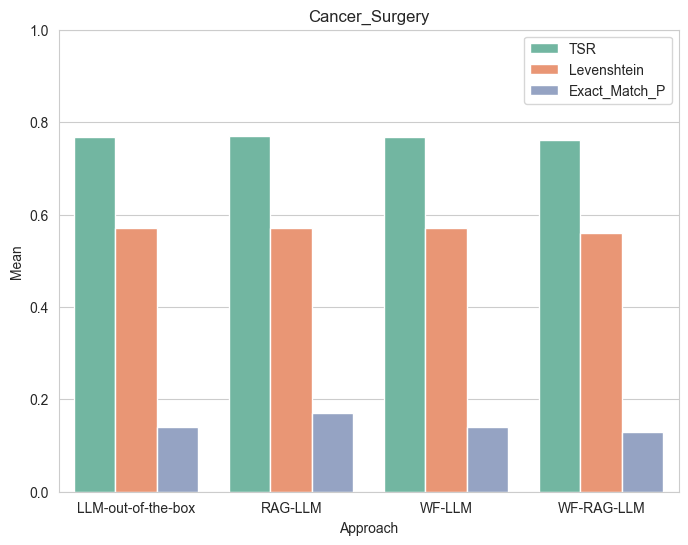

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\3492070194.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


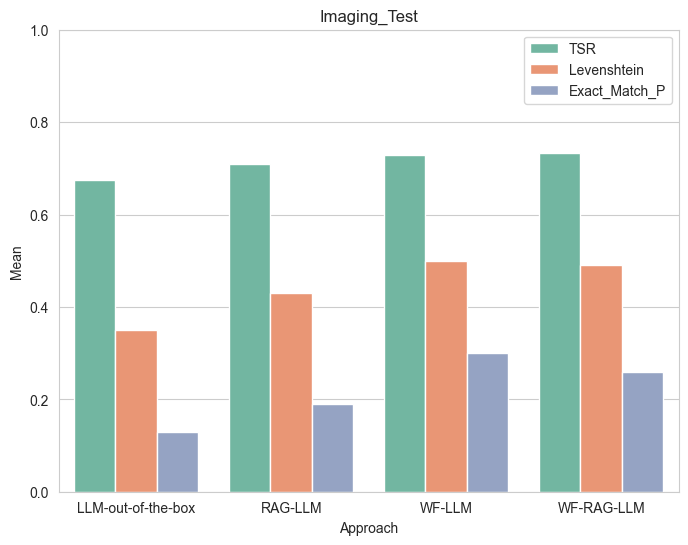

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\3492070194.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


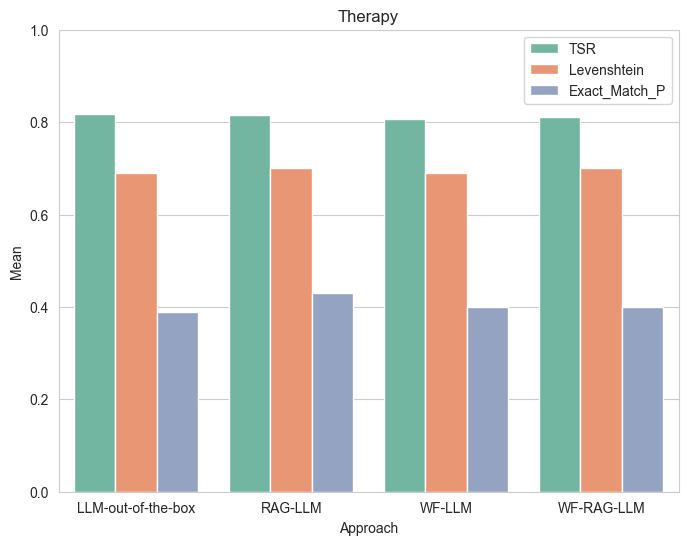

In [ ]:
# Images for Step 12
# Bring TSR to the same scale 
sem_data = sem_stats_step2.copy()
sem_data.loc[sem_data["Metric"]=="TSR", "Mean"] = sem_data.loc[sem_data["Metric"]=="TSR", "Mean"]/100
# print(sem_data.loc[sem_stats_step12["Metric"]=="TSR"][1:3])

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for l in step2_labels:
    data_plot = sem_data.loc[sem_data["Label"]==l]

    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Approach", y="Mean", hue="Metric",)
    plt.title(l)
    plt.ylim([0,1])
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
    ax.set_xticklabels(list(approaches_names_map.values()))
    plt.show()
    fig.savefig(f"results/Step12_{l}.png", dpi=600, format="png", bbox_inches='tight')
    
    


C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\114767106.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


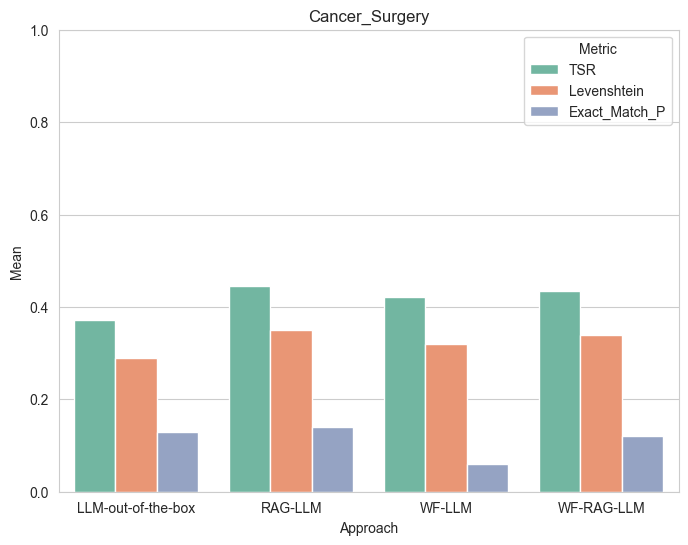

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\114767106.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


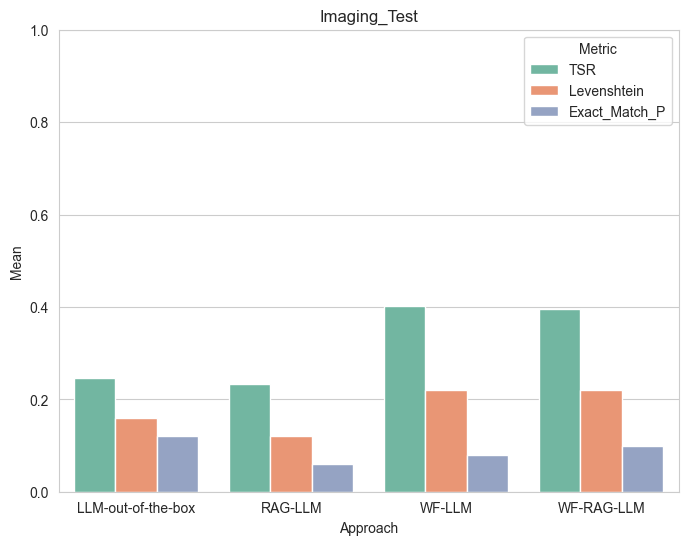

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\114767106.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


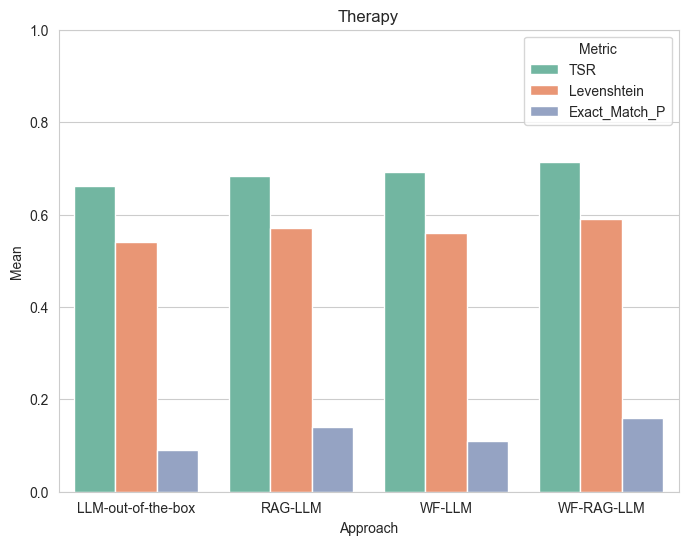

In [49]:
# Images for Step 3
# Bring TSR to the same scale 
sem_data = sem_stats_step3.copy()
sem_data.loc[sem_data["Metric"]=="TSR", "Mean"] = sem_data.loc[sem_data["Metric"]=="TSR", "Mean"]/100
# print(sem_data.loc[sem_stats_step12["Metric"]=="TSR"][1:3])

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for l in step12_labels:
    data_plot = sem_data.loc[sem_data["Label"]==l]

    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Approach", y="Mean", hue="Metric")
    plt.title(l)
    plt.ylim([0,1])
    ax.set_xticklabels(list(approaches_names_map.values()))
    plt.show()
    fig.savefig(f"results/Step3_{l}{a}.png", dpi=600, format="png", bbox_inches='tight')